Теперь мы работаем с объединенным датасетом, где собрана как динамика тренировок и платежей по каждому пользователю, так и информация о его сегменте: город, пол и возраст.

**Что надо сделать?**
1. Сравнить поведение клиентов из разных городов, а также проанализировать различия в среднем чеке и доле индивидуальных тренировок.
2. Разделить пользователей на возрастные группы (бины) и рассчитать ключевые метрики по бинам.
3. Изучить премиальный сегмент — выявить, что способствует высокому уровню жизненной ценности (LTR) у топ-клиентов.
4. Провести когортный анализ, чтобы оценить удержание пользователей со временем.

Загружаем датасет из файла merged_data.csv - в нем уже есть вся необходимая информация и он очищен от нуллов и выбросов.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### Задача 1. Различия по городам

Рассчитайте по каждому городу:

Средний чек в месяц на пользователя\
Долю индивидуальных тренировок от общего числа занятий\
Количество уникальных пользователей\
Постройте scatterplot, где:

Ось X — доля индивидуальных тренировок

Ось Y — средний чек

Цвет — город

Постройте пузырьковую диаграмму (bubble plot), где размер пузырька - это количество уникальных пользователей

In [3]:
#Группируем таблицу по пользователям
pay_user = df.groupby(['id_user', 'city']).agg({'mon':'count',
                                                'cnt_indiv':'sum',
                                                'cnt_total':'sum',
                                                'sum_total':'sum'}).reset_index().rename(columns={'mon':'nmonths'})
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,9,33,33,58600
1,1001,Москва,11,23,129,124800
2,1002,Москва,11,64,128,166000
3,1004,Екатеринбург,9,18,18,32000
4,1005,СПб,2,7,7,12600


In [4]:
# Добавляем столбы с долей инддив тренировок и средним платежом в месяц
pay_user['avg_pay'] = round(pay_user['sum_total']/pay_user['nmonths'], 2)
pay_user['share_indiv'] = pay_user['cnt_indiv']/pay_user['cnt_total']
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total,avg_pay,share_indiv
0,1000,СПб,9,33,33,58600,6511.11,1.000000
1,1001,Москва,11,23,129,124800,11345.45,0.178295
2,1002,Москва,11,64,128,166000,15090.91,0.500000
3,1004,Екатеринбург,9,18,18,32000,3555.56,1.000000
4,1005,СПб,2,7,7,12600,6300.00,1.000000


In [5]:
# Группируем таблицу по городам: считаем количество пользователей, средний платеж в месяц, долю индив тренировок
city_stat = pay_user.groupby('city').agg({'id_user':'nunique',
                                         'avg_pay':'mean',
                                         'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'cnt_user'})
city_stat.head()

,city,cnt_user,avg_pay,share_indiv
0,Екатеринбург,128,6735.819844,0.308108
1,Казань,127,6698.701339,0.247886
2,Москва,310,7194.958065,0.654638
3,СПб,273,7123.468828,0.333030


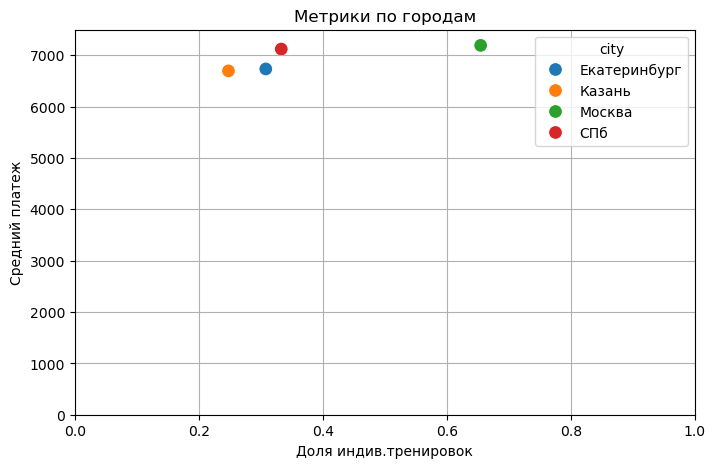

In [6]:
#Строим диаграмму рассеивания
plt.figure(figsize=(8, 5)) 
sns.scatterplot(data = city_stat,
               x = 'share_indiv',
               y = 'avg_pay',
               hue = 'city',
               s=100)
plt.xlabel('Доля индив.тренировок') # подписываем ось х
plt.ylabel('Средний платеж') # подписываем ось y
plt.title('Метрики по городам') #подписываем график
plt.grid(True) # добавляем сетку
plt.ylim(0,7500)  # начинаем ось Y с нуля
plt.xlim(0,1)
plt.show() # выводим график на экран


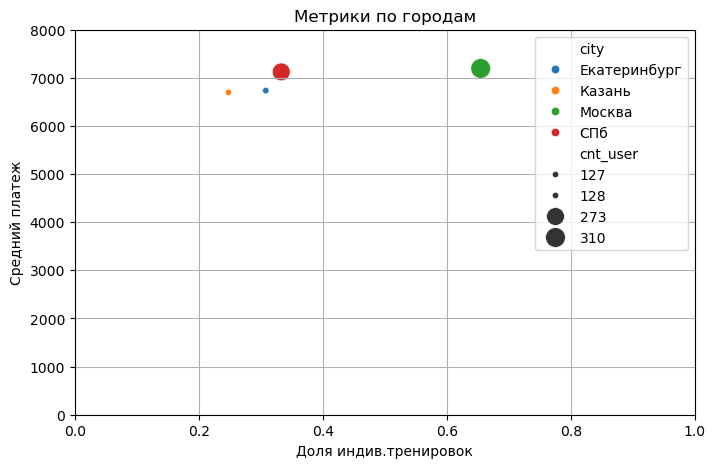

In [7]:
#Добавим третью переменную по количеству польхователей в городах, от этого будет зависеть размер кружка. Регилируем значением s
plt.figure(figsize=(8, 5)) 
plt.ylim(0,8000)  # начинаем ось Y с нуля
plt.xlim(0,1)
plt.grid(True) # добавляем сетку
plt.xlabel('Доля индив.тренировок') # подписываем ось х
plt.ylabel('Средний платеж') # подписываем ось y
plt.title('Метрики по городам') #подписываем график
sns.scatterplot(data = city_stat,
               x = 'share_indiv',
               y = 'avg_pay',
               hue = 'city',
               size = city_stat['cnt_user'],
               sizes=(20, 200))
plt.legend()
plt.show() # выводим график на экран

Наблюдаем региональные различия: в Москве и Спб ожидаемо болшее кол-во пользователей и более высокая доля индив. тренировок, особенно в Москве. Возможно имеет смысл больше ресурсов вкладывать в это направление (иметь больше тренеров, предлагать спец условия за индив занятия и т.д.). В остальных городах больше групповых тренировок. Возможно имеет смысл раширить ассортимент популярных занятий и/или расширить классы.

Также видим, что средний чек в Москве и Спб больше, скорее всего эти центры приносят больший вклад в выручку.

### Задача 2. сравнение по возрастным когортам

Изучаем ключевые метрики по возрастным группам

Разделите клиентов на три возрастные группы:

+ до 30 лет

+ от 30 до 45 лет

+ старше 45 лет

Для каждой возрастной группы рассчитайте:

+ Среднюю долю индивидуальных тренировок

+ Среднее количество тренировок в месяц

+ Средний месячный чек

+ Общее количество клиентов в группе

Представьте результаты в виде таблицы.
Сделайте выводы:

+ Как меняется поведение клиентов с возрастом?

+ Какие возрастные группы более склонны к индивидуальным тренировкам?

+ Есть ли возрастная группа с меньшей вовлечённостью, которую стоит дополнительно стимулировать?

In [8]:
df = pd.read_csv('merged_data.csv')

In [9]:
# Через функцию присваиваем пользователям возрастную группу
def user_group(age):
    if age<=30:
        return '18-30'
    elif (age>=31) & (age<=45):
        return '31-45'
    else:
        return '46+'
df['age_group'] = df['age'].apply(user_group)
df.head()
        

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_group
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31-45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45


In [10]:
age_user = df.groupby(['id_user', 'age_group']).agg({'mon':'count',
                                                'cnt_indiv':'sum',
                                                'cnt_total':'sum',
                                                'sum_total':'sum'}).reset_index().rename(columns={'mon':'nmonths'})
age_user.head()

,id_user,age_group,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,31-45,9,33,33,58600
1,1001,31-45,11,23,129,124800
2,1002,31-45,11,64,128,166000
3,1004,46+,9,18,18,32000
4,1005,31-45,2,7,7,12600


In [11]:
age_user['avg_pay'] = round(age_user['sum_total']/age_user['nmonths'], 2)
age_user['share_indiv'] = age_user['cnt_indiv']/age_user['cnt_total']
age_user['cnt_train_in_month'] = age_user['cnt_total']/age_user['nmonths']
age_user.head()

,id_user,age_group,nmonths,cnt_indiv,cnt_total,sum_total,avg_pay,share_indiv,cnt_train_in_month
0,1000,31-45,9,33,33,58600,6511.11,1.000000,3.666667
1,1001,31-45,11,23,129,124800,11345.45,0.178295,11.727273
2,1002,31-45,11,64,128,166000,15090.91,0.500000,11.636364
3,1004,46+,9,18,18,32000,3555.56,1.000000,2.000000
4,1005,31-45,2,7,7,12600,6300.00,1.000000,3.500000


In [12]:
age_segm = age_user.groupby('age_group').agg({'id_user':'nunique',
                                              'nmonths':'mean',
                                              'avg_pay':'mean',
                                              'cnt_train_in_month':'mean',
                                              'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'cnt_user'})
age_segm.head()

,age_group,cnt_user,nmonths,avg_pay,cnt_train_in_month,share_indiv
0,18-30,278,5.399281,8222.747698,7.290366,0.446690
1,31-45,271,5.343173,7774.985461,7.003930,0.445543
2,46+,289,5.681661,5173.422422,4.737098,0.414714


После разделения пользователей на возврастные группы видим, что больше всего денег в месяц тратят пользователи в возарсте от 18 до 30 лет и они же имеют максимальное количество тренировок в месяц. В целом первые две группы очень близки и по среднему и чеку и по кол-ву тренирвок в месяц. Проседает третья группа 46+,  у нее минимальный средний чек, так как и количество тренировок в месяц меньше, чем у первых двух групп. Аозможно имеет смысл каким-то образом стимулировать данную группу, предложив им пакетный вариант посещений, например с 2 тренировками в  неделю для повышения суммы оплаты в месяц

### Задача 3. Топ-10 пользователей по LTR

Изучаем премиальный сегмент

+ Найдите 10 пользователей с самой высокой совокупной выручкой (LTR). Используйте сумму всех платежей пользователя за весь период.
+ Сохраните их id-шники в формате список
+ Выведите для этих пользователей город, пол, средний чек за месяц, среднее количество тренировок в месяц и количество месяцев, которые они тренировались.

In [13]:
#Отбираем 10 пользователей с самым высоким LTR
df_gr = df.groupby('id_user').agg({'sum_total':'sum'}).reset_index().sort_values('sum_total', ascending = False).head(10)

In [14]:
df_gr

,id_user,sum_total
2,1002,166000
551,1657,164200
319,1381,147600
135,1153,147400
420,1506,146400
27,1029,140000
12,1013,139800
485,1582,136200
446,1536,134400
402,1482,131400


In [15]:
user_lst = df_gr['id_user'].tolist() #Сохраняем их id в список
user_lst

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [16]:
#Отбираем из общей талицы только этих пользователей
df_top = df[df['id_user'].isin(user_lst)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_group
20,1002,2023-02,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
21,1002,2023-03,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
22,1002,2023-04,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45
23,1002,2023-05,2,10,1600,16000,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
24,1002,2023-06,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45


In [26]:
top_user = df_top.groupby(['id_user', 'city','gender', 'age_group']).agg({'mon':'count', 
                                                                         'cnt_total':'sum',
                                                                         'cnt_indiv':'sum',
                                                                         'sum_total':'sum'}).reset_index().\
                            rename(columns = {'mon':'nmonths'})
top_user['share_indive'] = top_user['cnt_indiv']/top_user['cnt_total']
top_user

,id_user,city,gender,age_group,nmonths,cnt_total,cnt_indiv,sum_total,share_indive
0,1002,Москва,male,31-45,11,128,64,166000,0.500000
1,1013,Москва,male,31-45,11,151,19,139800,0.125828
2,1029,СПб,female,31-45,8,126,40,140000,0.317460
3,1153,СПб,male,46+,12,118,53,147400,0.449153
4,1381,Москва,female,18-30,12,159,22,147600,0.138365
5,1482,Москва,female,18-30,11,110,46,131400,0.418182
6,1506,Москва,female,18-30,10,138,36,146400,0.260870
7,1536,Москва,female,18-30,9,125,37,134400,0.296000
8,1582,Екатеринбург,male,31-45,8,127,34,136200,0.267717
9,1657,СПб,male,18-30,10,144,53,164200,0.368056


In [18]:
top_user['avg_pay'] = round(top_user['sum_total']/top_user['nmonths'], 2)
top_user['cnt_train_in_month'] = round(top_user['cnt_total']/top_user['nmonths'],0)
top_user

,id_user,city,gender,age_group,nmonths,cnt_total,sum_total,avg_pay,cnt_train_in_month
0,1002,Москва,male,31-45,11,128,166000,15090.91,12.0
1,1013,Москва,male,31-45,11,151,139800,12709.09,14.0
2,1029,СПб,female,31-45,8,126,140000,17500.00,16.0
3,1153,СПб,male,46+,12,118,147400,12283.33,10.0
4,1381,Москва,female,18-30,12,159,147600,12300.00,13.0
5,1482,Москва,female,18-30,11,110,131400,11945.45,10.0
6,1506,Москва,female,18-30,10,138,146400,14640.00,14.0
7,1536,Москва,female,18-30,9,125,134400,14933.33,14.0
8,1582,Екатеринбург,male,31-45,8,127,136200,17025.00,16.0
9,1657,СПб,male,18-30,10,144,164200,16420.00,14.0


In [19]:
top_user['city'].value_counts()

city
Москва          6
СПб             3
Екатеринбург    1
Name: count, dtype: int64

In [20]:
top_user['gender'].value_counts()

gender
male      5
female    5
Name: count, dtype: int64

In [21]:
top_user['age_group'].value_counts()

age_group
18-30    5
31-45    4
46+      1
Name: count, dtype: int64

На основании анализа показателей топ-10 пользователей по LTR видим, что высокий LTR достигается за счет большого количесттва тренировок в месяц от 10 до 16 и длительными посещениями, при этом пол не имеет значение (распределение 5/5). Ожидаемо, что почти все пользователи 9 из 10 из первых двух возрастных групп и большиство из них находится в Москве и Спб. 

### Задача 4. Анализ доходимости когорт

Изучаем удержание пользователей после первого месяца тренировок:

Что нужно сделать:

+ Создать когорту для каждого пользователя — определить месяц их первого визита (min_mon).
+ Рассчитать индекс когорты (cohort_index), который показывает, какой по счёту месяц после первого визита рассматривается для каждого пользователя.
+ Для каждой когорты и каждого месяца жизни посчитать количество уникальных активных пользователей.
+ Построить когортную таблицу удержания — показать, какая доля пользователей осталась активной в каждом следующем месяце после первого визита.
+ Визуализировать результаты в виде тепловой карты с retention за первые 4 месяца для каждой когорты.

In [28]:
df['mon'] = pd.to_datetime(df['mon'], format = '%Y-%m')
df['min_mon'] = pd.to_datetime(df['min_mon'], format = '%Y-%m')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_group
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45


In [33]:
#Добавляем столбец, который показывает какой по счету месяц занимается пользователь
df['cohort_index']= df['mon'].dt.month - df['min_mon'].dt.month #из номера текущего месяца вычитаем номер первого месяца 
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_group,cohort_index
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,0
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,1
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45,2
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,3
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,4


In [34]:
#Группируем данные по месяцу начала занятий (когорта) и cohort_index
cohort_stat = df.groupby(['min_mon', 'cohort_index']).agg(active_user = ('id_user', 'nunique')).reset_index()
cohort_stat.head()

,min_mon,cohort_index,active_user
0,2023-01-01,0,337
1,2023-01-01,1,262
2,2023-01-01,2,205
3,2023-01-01,3,168
4,2023-01-01,4,159


In [37]:
#В head видим январcкую когорту, в январе пришло 337 пользователй, в фервале из них осталось 262, в марте 205 и т.д,
# т.е. сколько человек остается в каждом последующем месяце

In [31]:
# Создадим еще одну таблицу с изначальным размером когорт
cohort_size = cohort_stat[cohort_stat['cohort_index']==0][['min_mon','active_user']].\
                                    rename(columns = {'active_user':'cohsize'})
cohort_size

,min_mon,cohsize
0,2023-01-01,337
12,2023-02-01,88
23,2023-03-01,83
33,2023-04-01,62
42,2023-05-01,57
50,2023-06-01,51
57,2023-07-01,48
63,2023-08-01,35
68,2023-09-01,28
72,2023-10-01,27


In [38]:
#Соединим таблицы. В результате получим доп столбец в первой таблице с изначальным размером когорты. Нужен нам для дальнейшего расчета ретеншн
cohort_data = cohort_stat.merge(cohort_size, on = 'min_mon')
cohort_data.head()

,min_mon,cohort_index,active_user,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [39]:
cohort_data['retention'] = cohort_data['active_user']/cohort_data['cohsize']

In [40]:
cohort_data.head()

,min_mon,cohort_index,active_user,cohsize,retention
0,2023-01-01,0,337,337,1.000000
1,2023-01-01,1,262,337,0.777448
2,2023-01-01,2,205,337,0.608309
3,2023-01-01,3,168,337,0.498516
4,2023-01-01,4,159,337,0.471810


In [41]:
retantion_table = pd.pivot_table(cohort_data, index = 'min_mon', columns = 'cohort_index', values = 'retention')

In [42]:
retantion_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
min_mon,,,,,,,,,,,,
2023-01-01,1.0,0.777448,0.608309,0.498516,0.471810,0.454006,0.489614,0.465875,0.448071,0.483680,0.451039,0.397626
2023-02-01,1.0,0.761364,0.602273,0.568182,0.579545,0.522727,0.522727,0.545455,0.522727,0.443182,0.431818,NaN
2023-03-01,1.0,0.746988,0.590361,0.578313,0.542169,0.506024,0.481928,0.493976,0.469880,0.481928,NaN,NaN
2023-04-01,1.0,0.725806,0.645161,0.548387,0.564516,0.580645,0.548387,0.435484,0.419355,NaN,NaN,NaN
2023-05-01,1.0,0.701754,0.561404,0.614035,0.614035,0.614035,0.578947,0.315789,NaN,NaN,NaN,NaN
2023-06-01,1.0,0.823529,0.705882,0.549020,0.470588,0.490196,0.411765,NaN,NaN,NaN,NaN,NaN
2023-07-01,1.0,0.770833,0.666667,0.666667,0.625000,0.437500,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01,1.0,0.885714,0.571429,0.400000,0.342857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,1.0,0.678571,0.500000,0.464286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
retantion_table.index = retantion_table.index.strftime('%Y-%m')

In [45]:
retantion_table.iloc[:,:4] # берем для дальнейшей визуализации только первые 4 месяца для каждой когорты

cohort_index,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


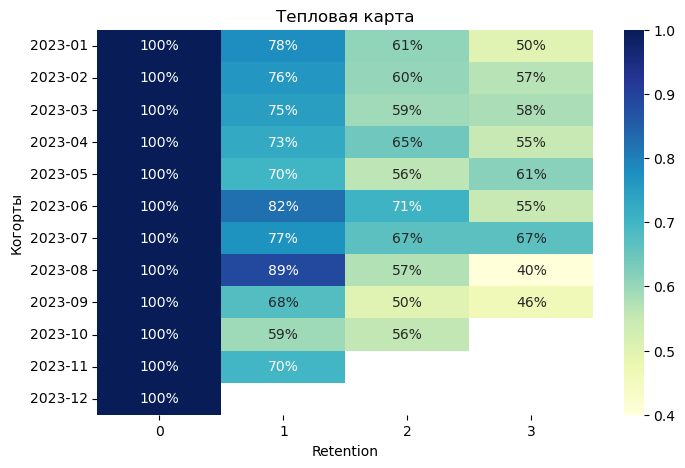

In [46]:
plt.figure(figsize=(8, 5)) 
sns.heatmap(retantion_table.iloc[:,:4], annot = True, fmt = '.0%', cmap = 'YlGnBu')
plt.xlabel('Retention') # подписываем ось х
plt.ylabel('Когорты') # подписываем ось y
plt.title('Тепловая карта') #подписываем график
plt.show() # выводим график на экран